# Lock-in Characterization — Optimal Tau & Slope Finder
Runs two experiments per `(Tau, slope)` candidate:
1. **Settling time** — log R(t) right after a frequency step, find when the output truly stabilizes
2. **Noise floor** — park at a fixed frequency, take many readings, compute SNR

Final cell auto-recommends the fastest valid setting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pyvisa
import time
import pickle
import os
from itertools import product
from datetime import datetime

In [7]:
rm = pyvisa.ResourceManager()
rm.list_resources()

('USB0::0x0699::0x0346::C036493::INSTR', 'ASRL1::INSTR', 'GPIB0::8::INSTR')

In [8]:
# --- Instrument connections (reuse from sweep setup if already open) ---
inst   = rm.open_resource("GPIB0::8::INSTR")
inst.write_termination = "\n"
inst.read_termination  = "\n"
fungen = rm.open_resource("USB0::0x0699::0x0346::C036493::INSTR")

In [16]:
# ============================================================
# CONFIGURATION — edit this cell to adjust the experiment
# ============================================================

# Candidate filter settings to test
# (label, OFLT code, tau_seconds, OFSL code, slope_label)
CANDIDATES = [
    ("10ms / 12dB",  10, 0.010, 1, "12 dB/oct"),
    ("10ms / 18dB",  10, 0.010, 2, "18 dB/oct"),
    ("10ms / 24dB",  10, 0.010, 3, "24 dB/oct"),
    ("30ms / 12dB",  10, 0.030, 1, "12 dB/oct"),
    ("30ms / 18dB",  10, 0.030, 2, "18 dB/oct"),
    ("30ms / 24dB",  10, 0.030, 3, "24 dB/oct"),
    ("100ms / 12dB", 10, 0.100, 1, "12 dB/oct"),
    ("100ms / 18dB", 10, 0.100, 2, "18 dB/oct"),
    ("100ms / 24dB", 10, 0.100, 3, "24 dB/oct"),  # ← your current setting
]

# Test frequencies: pick 3 representative points from your sweep
# (off-resonance, at resonance, at anti-resonance)
TEST_FREQS = {
    "off-res":       49600.0,
    "resonance":     50095.0,
    "anti-resonance":50280.0,
}

# Settling criterion: fraction of final value within which we call it "settled"
SETTLE_THRESHOLD = 0.01   # 1 %

# Minimum acceptable SNR (mean / std) for noise floor test
SNR_MIN = 50.0

# Number of samples for noise floor test
N_NOISE_SAMPLES = 300

# How many multiples of Tau to log the settling transient
SETTLE_LOG_MULTIPLES = 15

# Sensitivity for each test frequency — match your sweep
SENS_MAP = {
    "off-res":        "SENS 26",  # 1 V
    "resonance":      "SENS 19",  # 5 mV
    "anti-resonance": "SENS 17",  # 1 mV
}

In [17]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_lockin():
    """Read X, Y, R, Theta from lock-in."""
    x, y, r, theta = map(float, inst.query("SNAP? 1,2,3,4").split(","))
    return x, y, r, theta


def set_filter(oflt_code, ofsl_code, sens_cmd=None):
    """Apply Tau and slope settings, optionally set sensitivity."""
    inst.write(f"OFLT {oflt_code}")
    inst.write(f"OFSL {ofsl_code}")
    if sens_cmd:
        inst.write(sens_cmd)


def measure_transient(from_freq, to_freq, log_duration_s, sens_cmd=None):
    """
    Step from from_freq → to_freq, then log R(t) as fast as possible
    for log_duration_s seconds. Returns (times, R_values).
    """
    # Start parked at from_freq, already settled
    fungen.write(f"SOURCE1:FREQ {from_freq}")
    time.sleep(0.5)  # brief settle at start freq

    if sens_cmd:
        inst.write(sens_cmd)

    # Step!
    t0 = time.perf_counter()
    fungen.write(f"SOURCE1:FREQ {to_freq}")

    times, R_vals = [], []
    while time.perf_counter() - t0 < log_duration_s:
        t = time.perf_counter() - t0
        r = get_lockin()[2]
        times.append(t)
        R_vals.append(r)

    return np.array(times), np.array(R_vals)


def measure_noise_floor(freq, n_samples, settle_time_s, sens_cmd=None):
    """
    Park at freq, wait for filter to settle, take n_samples rapid readings.
    Returns array of R values.
    """
    fungen.write(f"SOURCE1:FREQ {freq}")
    if sens_cmd:
        inst.write(sens_cmd)
    time.sleep(settle_time_s)

    return np.array([get_lockin()[2] for _ in range(n_samples)])


def find_settling_time(times, R_vals, threshold=0.01):
    """
    Find the time after which R stays within `threshold` fraction of
    the final value (median of last 20% of samples).
    Returns settling time in seconds, or np.nan if never settled.
    """
    R_final = np.median(R_vals[int(0.8 * len(R_vals)):])
    if R_final == 0:
        return np.nan
    settled_mask = np.abs(R_vals - R_final) / np.abs(R_final) < threshold
    # Find last index where it was NOT settled, then +1
    not_settled = np.where(~settled_mask)[0]
    if len(not_settled) == 0:
        return times[0]  # settled immediately
    last_unsettled = not_settled[-1]
    if last_unsettled + 1 >= len(times):
        return np.nan  # never settled within log window
    return times[last_unsettled + 1]


print("Helpers defined ✓")

Helpers defined ✓


In [18]:
# ============================================================
# EXPERIMENT 1 — SETTLING TIME
# ============================================================
# For each (candidate, test_freq): step the frequency and log the transient.
# We step FROM a neutral off-resonance point TO the test frequency.

settling_results = {}  # key: (label, freq_name) → (times, R_vals, t_settle)

total_runs = len(CANDIDATES) * len(TEST_FREQS)
run = 0

inst.write("*RST")
time.sleep(1)
inst.write("FMOD 0")
inst.write("RMOD 1")
inst.write("RSLP 1")

for label, oflt, tau, ofsl, slope_label in CANDIDATES:
    log_duration = SETTLE_LOG_MULTIPLES * tau

    for freq_name, freq in TEST_FREQS.items():
        run += 1
        sens_cmd = SENS_MAP[freq_name]

        # Configure filter for this candidate
        set_filter(oflt, ofsl, sens_cmd="SENS 26")  # start at 1V sensitivity
        # Give the filter a moment to switch
        time.sleep(5 * tau)

        print(f"[{run}/{total_runs}] Settling: {label} | {freq_name} ({freq} Hz) ...", end=" ")

        # Step from off-res starting point to target freq
        from_freq = 49600.0 if freq_name != "off-res" else 51000.0
        times, R_vals = measure_transient(from_freq, freq, log_duration, sens_cmd=sens_cmd)

        t_settle = find_settling_time(times, R_vals, threshold=SETTLE_THRESHOLD)
        settling_results[(label, freq_name)] = (times, R_vals, t_settle)

        print(f"settled at {t_settle*1000:.1f} ms" if not np.isnan(t_settle)
              else "⚠️  did not settle in window")

print("\n✓ Settling experiment done")

[1/27] Settling: 10ms / 12dB | off-res (49600.0 Hz) ... settled at 0.1 ms
[2/27] Settling: 10ms / 12dB | resonance (50095.0 Hz) ... settled at 0.1 ms
[3/27] Settling: 10ms / 12dB | anti-resonance (50280.0 Hz) ... settled at 0.2 ms
[4/27] Settling: 10ms / 18dB | off-res (49600.0 Hz) ... settled at 0.2 ms
[5/27] Settling: 10ms / 18dB | resonance (50095.0 Hz) ... settled at 0.1 ms
[6/27] Settling: 10ms / 18dB | anti-resonance (50280.0 Hz) ... settled at 0.2 ms
[7/27] Settling: 10ms / 24dB | off-res (49600.0 Hz) ... settled at 0.2 ms
[8/27] Settling: 10ms / 24dB | resonance (50095.0 Hz) ... settled at 0.2 ms
[9/27] Settling: 10ms / 24dB | anti-resonance (50280.0 Hz) ... settled at 0.2 ms
[10/27] Settling: 30ms / 12dB | off-res (49600.0 Hz) ... ⚠️  did not settle in window
[11/27] Settling: 30ms / 12dB | resonance (50095.0 Hz) ... settled at 0.2 ms
[12/27] Settling: 30ms / 12dB | anti-resonance (50280.0 Hz) ... settled at 0.2 ms
[13/27] Settling: 30ms / 18dB | off-res (49600.0 Hz) ... settl

In [19]:
# ============================================================
# EXPERIMENT 2 — NOISE FLOOR
# ============================================================
# For each candidate, park at the WORST-CASE frequency (anti-resonance,
# lowest sensitivity) and measure the noise.

noise_results = {}  # key: label → {'R_samples', 'mean', 'std', 'snr'}

NOISE_TEST_FREQ     = TEST_FREQS["anti-resonance"]
NOISE_TEST_SENS_CMD = SENS_MAP["anti-resonance"]

for i, (label, oflt, tau, ofsl, slope_label) in enumerate(CANDIDATES):
    print(f"[{i+1}/{len(CANDIDATES)}] Noise floor: {label} ...", end=" ")

    set_filter(oflt, ofsl, sens_cmd=NOISE_TEST_SENS_CMD)
    settle_time = 10 * tau

    R_samples = measure_noise_floor(
        NOISE_TEST_FREQ, N_NOISE_SAMPLES,
        settle_time_s=settle_time,
        sens_cmd=NOISE_TEST_SENS_CMD
    )

    mean = np.mean(R_samples)
    std  = np.std(R_samples, ddof=1)
    snr  = mean / std if std > 0 else np.inf

    noise_results[label] = {
        'R_samples': R_samples,
        'mean': mean,
        'std':  std,
        'snr':  snr,
    }

    print(f"mean={mean:.5f} V | std={std:.5f} V | SNR={snr:.1f}")

print("\n✓ Noise floor experiment done")

[1/9] Noise floor: 10ms / 12dB ... mean=0.00023 V | std=0.00034 V | SNR=0.7
[2/9] Noise floor: 10ms / 18dB ... mean=0.00003 V | std=0.00002 V | SNR=2.0
[3/9] Noise floor: 10ms / 24dB ... mean=0.00004 V | std=0.00001 V | SNR=6.5
[4/9] Noise floor: 30ms / 12dB ... mean=0.00006 V | std=0.00000 V | SNR=179.9
[5/9] Noise floor: 30ms / 18dB ... mean=0.00006 V | std=0.00000 V | SNR=319.8
[6/9] Noise floor: 30ms / 24dB ... mean=0.00005 V | std=0.00000 V | SNR=11.0
[7/9] Noise floor: 100ms / 12dB ... mean=0.00006 V | std=0.00000 V | SNR=390.2
[8/9] Noise floor: 100ms / 18dB ... mean=0.00006 V | std=0.00000 V | SNR=1338.2
[9/9] Noise floor: 100ms / 24dB ... mean=0.00006 V | std=0.00000 V | SNR=1864.4

✓ Noise floor experiment done


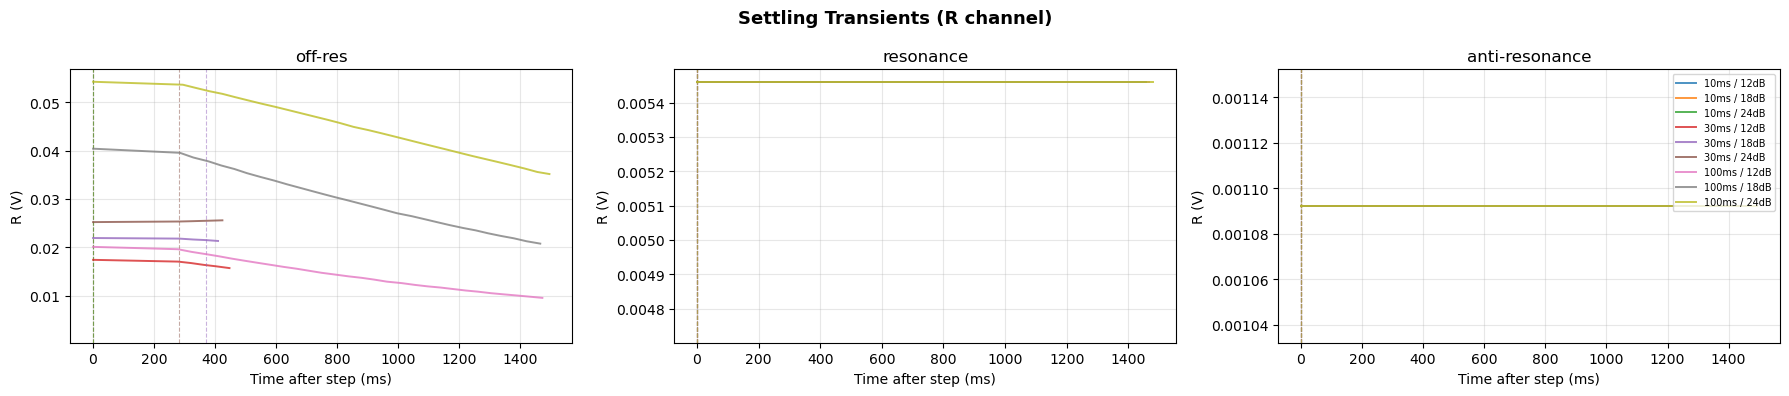

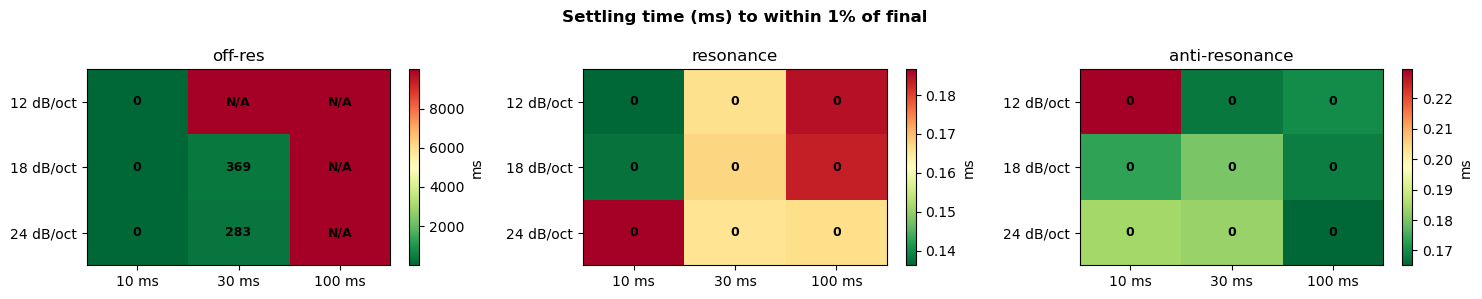

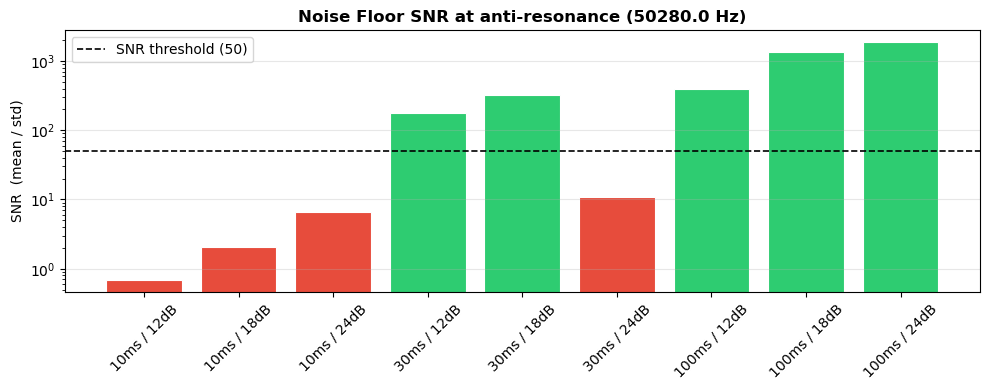

Plots saved ✓


In [20]:
# ============================================================
# PLOTS
# ============================================================

COLORS = plt.cm.tab10.colors

# --- Plot 1: Settling transients per test frequency ---
fig, axes = plt.subplots(1, len(TEST_FREQS), figsize=(6 * len(TEST_FREQS), 4), sharey=False)
fig.suptitle("Settling Transients (R channel)", fontsize=13, fontweight="bold")

for ax, freq_name in zip(axes, TEST_FREQS):
    for ci, (label, oflt, tau, ofsl, _) in enumerate(CANDIDATES):
        times, R_vals, t_settle = settling_results[(label, freq_name)]
        ax.plot(times * 1e3, R_vals, color=COLORS[ci % 10], alpha=0.8,
                lw=1.4, label=label)
        if not np.isnan(t_settle):
            ax.axvline(t_settle * 1e3, color=COLORS[ci % 10], lw=0.8, ls="--", alpha=0.5)

    ax.set_title(freq_name)
    ax.set_xlabel("Time after step (ms)")
    ax.set_ylabel("R (V)")
    ax.grid(True, alpha=0.3)

axes[-1].legend(loc="upper right", fontsize=7, ncol=1)
plt.tight_layout()
plt.savefig("settling_transients.png", dpi=150)
plt.show()


# --- Plot 2: Settling time summary heatmap ---
tau_vals   = sorted(set(c[2] for c in CANDIDATES))
slope_vals = sorted(set(c[3] for c in CANDIDATES))
slope_labels = {1: "12 dB/oct", 2: "18 dB/oct", 3: "24 dB/oct"}
tau_labels   = {0.010: "10 ms", 0.030: "30 ms", 0.100: "100 ms"}

fig, axes = plt.subplots(1, len(TEST_FREQS), figsize=(5 * len(TEST_FREQS), 3))
fig.suptitle(f"Settling time (ms) to within {SETTLE_THRESHOLD*100:.0f}% of final",
             fontsize=12, fontweight="bold")

for ax, freq_name in zip(axes, TEST_FREQS):
    matrix = np.full((len(slope_vals), len(tau_vals)), np.nan)
    for ci, (label, oflt, tau, ofsl, _) in enumerate(CANDIDATES):
        _, _, t_settle = settling_results[(label, freq_name)]
        ri = slope_vals.index(ofsl)
        ci_ = tau_vals.index(tau)
        matrix[ri, ci_] = t_settle * 1e3 if not np.isnan(t_settle) else 9999

    im = ax.imshow(matrix, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(tau_vals)))
    ax.set_yticks(range(len(slope_vals)))
    ax.set_xticklabels([tau_labels[t] for t in tau_vals])
    ax.set_yticklabels([slope_labels[s] for s in slope_vals])
    ax.set_title(freq_name)
    for r in range(len(slope_vals)):
        for c in range(len(tau_vals)):
            val = matrix[r, c]
            txt = f"{val:.0f}" if val < 9000 else "N/A"
            ax.text(c, r, txt, ha="center", va="center", fontsize=9, fontweight="bold")
    plt.colorbar(im, ax=ax, label="ms")

plt.tight_layout()
plt.savefig("settling_heatmap.png", dpi=150)
plt.show()


# --- Plot 3: SNR bar chart ---
labels = [c[0] for c in CANDIDATES]
snrs   = [noise_results[l]['snr'] for l in labels]
colors = ["#2ecc71" if s >= SNR_MIN else "#e74c3c" for s in snrs]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, snrs, color=colors, edgecolor="white", linewidth=0.8)
ax.axhline(SNR_MIN, color="black", ls="--", lw=1.2, label=f"SNR threshold ({SNR_MIN:.0f})")
ax.set_ylabel("SNR  (mean / std)")
ax.set_title(f"Noise Floor SNR at anti-resonance ({NOISE_TEST_FREQ} Hz)",
             fontweight="bold")
ax.set_yscale("log")
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("noise_snr.png", dpi=150)
plt.show()

print("Plots saved ✓")

In [ ]:
# ============================================================
# AUTO-RECOMMENDATION
# ============================================================
# A candidate is VALID if:
#   - SNR >= SNR_MIN at the worst-case frequency
#   - Settling time < 5 * Tau at ALL test frequencies
# Among valid ones, pick the one with the smallest time_per_point
# (WAIT = 10*Tau + 5 measurements * Tau = 15*Tau)

N_MEAS     = 2
INTER_DT   = 1   # multiples of Tau between measurements
WAIT_MULT  = 10  # multiples of Tau for settle wait

print("=" * 60)
print("CANDIDATE EVALUATION")
print("=" * 60)

valid = []

for label, oflt, tau, ofsl, slope_label in CANDIDATES:
    snr = noise_results[label]['snr']
    snr_ok = snr >= SNR_MIN

    settle_times = {
        fn: settling_results[(label, fn)][2]
        for fn in TEST_FREQS
    }
    worst_settle = max(
        (t for t in settle_times.values() if not np.isnan(t)),
        default=np.nan
    )
    settle_ok = (not np.isnan(worst_settle)) and (worst_settle <= 5 * tau)

    time_per_point = (WAIT_MULT + N_MEAS * INTER_DT) * tau
    total_min = (746 * time_per_point) / 60  # assumes 746 points

    status = "✅ VALID" if (snr_ok and settle_ok) else "❌"
    if not snr_ok:
        status += " (SNR too low)"
    if not settle_ok:
        status += " (doesn't settle in 5×Tau)"

    print(f"{label:20s} | SNR={snr:6.1f} | worst settle={worst_settle*1e3:.1f}ms"
          f" | {time_per_point:.3f}s/pt | ~{total_min:.1f}min  {status}")

    if snr_ok and settle_ok:
        valid.append((label, oflt, tau, ofsl, slope_label, time_per_point, total_min))

print()

if valid:
    best = min(valid, key=lambda x: x[5])  # smallest time_per_point
    label, oflt, tau, ofsl, slope_label, tpp, total_min = best
    print("=" * 60)
    print(f"🏆  RECOMMENDED SETTING: {label}")
    print(f"    OFLT {oflt}  ({tau*1000:.0f} ms Tau)")
    print(f"    OFSL {ofsl}  ({slope_label})")
    print(f"    Time per point : {tpp:.3f} s")
    print(f"    Estimated sweep: ~{total_min:.1f} min")
    print("=" * 60)
else:
    print("⚠️  No candidate passed both criteria.")
    print("    Consider lowering SNR_MIN or increasing SETTLE_LOG_MULTIPLES.")

CANDIDATE EVALUATION
10ms / 12dB          | SNR=   0.7 | worst settle=0.2ms | 0.150s/pt | ~1.9min  ❌ (SNR too low)
10ms / 18dB          | SNR=   2.0 | worst settle=0.2ms | 0.150s/pt | ~1.9min  ❌ (SNR too low)
10ms / 24dB          | SNR=   6.5 | worst settle=0.2ms | 0.150s/pt | ~1.9min  ❌ (SNR too low)
30ms / 12dB          | SNR= 179.9 | worst settle=0.2ms | 0.450s/pt | ~5.6min  ✅ VALID
30ms / 18dB          | SNR= 319.8 | worst settle=368.7ms | 0.450s/pt | ~5.6min  ❌ (doesn't settle in 5×Tau)
30ms / 24dB          | SNR=  11.0 | worst settle=283.1ms | 0.450s/pt | ~5.6min  ❌ (SNR too low) (doesn't settle in 5×Tau)
100ms / 12dB         | SNR= 390.2 | worst settle=0.2ms | 1.500s/pt | ~18.6min  ✅ VALID
100ms / 18dB         | SNR=1338.2 | worst settle=0.2ms | 1.500s/pt | ~18.6min  ✅ VALID
100ms / 24dB         | SNR=1864.4 | worst settle=0.2ms | 1.500s/pt | ~18.6min  ✅ VALID

🏆  RECOMMENDED SETTING: 30ms / 12dB
    OFLT 10  (30 ms Tau)
    OFSL 1  (12 dB/oct)
    Time per point : 0.450 s
    E

In [ ]:
# ============================================================
# SAVE RESULTS
# ============================================================
timestamp = datetime.now().strftime("%Hh_%Mm_%Ss")
save_path = f"characterization_{timestamp}.pkl"

results_bundle = {
    'candidates':       CANDIDATES,
    'test_freqs':       TEST_FREQS,
    'settling_results': {
        k: {'times': v[0], 'R_vals': v[1], 't_settle': v[2]}
        for k, v in settling_results.items()
    },
    'noise_results': noise_results,
    'config': {
        'settle_threshold': SETTLE_THRESHOLD,
        'snr_min':          SNR_MIN,
        'n_noise_samples':  N_NOISE_SAMPLES,
    }
}

with open(save_path, "wb") as f:
    pickle.dump(results_bundle, f)

print(f"Results saved → {save_path}")